# Mini Assignment: Gold Price Analysis
**Student ID:** [2471369]  
**Name:** [Fu Tianyi]  
[cite_start]**Track:** Track 2 - GitHub Data Analysis Project [cite: 500]

In [7]:
# ==========================================
# CELL 1: Import Libraries and Load Local Data
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

print("Step 1: Initializing and loading local data files...")

try:
    # 1. Load China Gold ETF Data
    df_china = pd.read_csv('china_gold_etf.csv')
    df_china['Date'] = pd.to_datetime(df_china['Date'])
    df_china.set_index('Date', inplace=True)
    
    # 2. Load US WRDS GLD Data
    df_us = pd.read_csv('wrds_gld_data.csv')
    df_us['date'] = pd.to_datetime(df_us['date'])
    df_us.set_index('date', inplace=True)
    # 处理 WRDS 数据中的负值符号
    df_us['Close_US'] = df_us['PRC'].abs()
    
    print("✅ Data loaded successfully! Ready for processing.")

except FileNotFoundError:
    print("❌ Error: CSV files not found. Please ensure they are in the same folder.")

Step 1: Initializing and loading local data files...
✅ Data loaded successfully! Ready for processing.


In [10]:
# ==========================================
# CELL 2: Advanced Data Processing & Indicators
# ==========================================
print("\nStep 2: Calculating advanced technical indicators...")

try:
    # 1. Moving Averages (Trend)
    df_china['MA50'] = df_china['Close'].rolling(window=50).mean()
    df_china['MA200'] = df_china['Close'].rolling(window=200).mean()
    
    # 2. Bollinger Bands (Volatility & Momentum)
    df_china['STD'] = df_china['Close'].rolling(window=20).std()
    df_china['Upper_Band'] = df_china['MA50'] + (df_china['STD'] * 2)
    df_china['Lower_Band'] = df_china['MA50'] - (df_china['STD'] * 2)
    
    # 3. Relative Strength Index (RSI - 14 Days)
    delta = df_china['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df_china['RSI'] = 100 - (100 / (1 + rs))

    # 4. Daily Returns & Rolling Volatility (Risk)
    df_china['Returns'] = df_china['Close'].pct_change()
    df_china['Volatility'] = df_china['Returns'].rolling(window=22).std() * np.sqrt(252) # Annualized
    
    # 5. 【新增核心代码】计算累计收益率，确保 Cell 3 不报错且图表不为空
    df_china['Cum_Returns'] = (1 + df_china['Returns']).cumprod() - 1

    # 6. Merge China and US datasets (Cross-Market)
    df_merged = pd.merge(df_china[['Close']], df_us[['Close_US']], left_index=True, right_index=True, how='inner')
    df_merged['China_Norm'] = (df_merged['Close'] / df_merged['Close'].iloc[0]) * 100
    df_merged['US_Norm'] = (df_merged['Close_US'] / df_merged['Close_US'].iloc[0]) * 100

    print("✅ Advanced indicators calculated successfully!")

except Exception as e:
    print(f"❌ Error during calculations: {e}")


Step 2: Calculating advanced technical indicators...
✅ Advanced indicators calculated successfully!



Step 3: Generating the 8-Chart Dashboard...


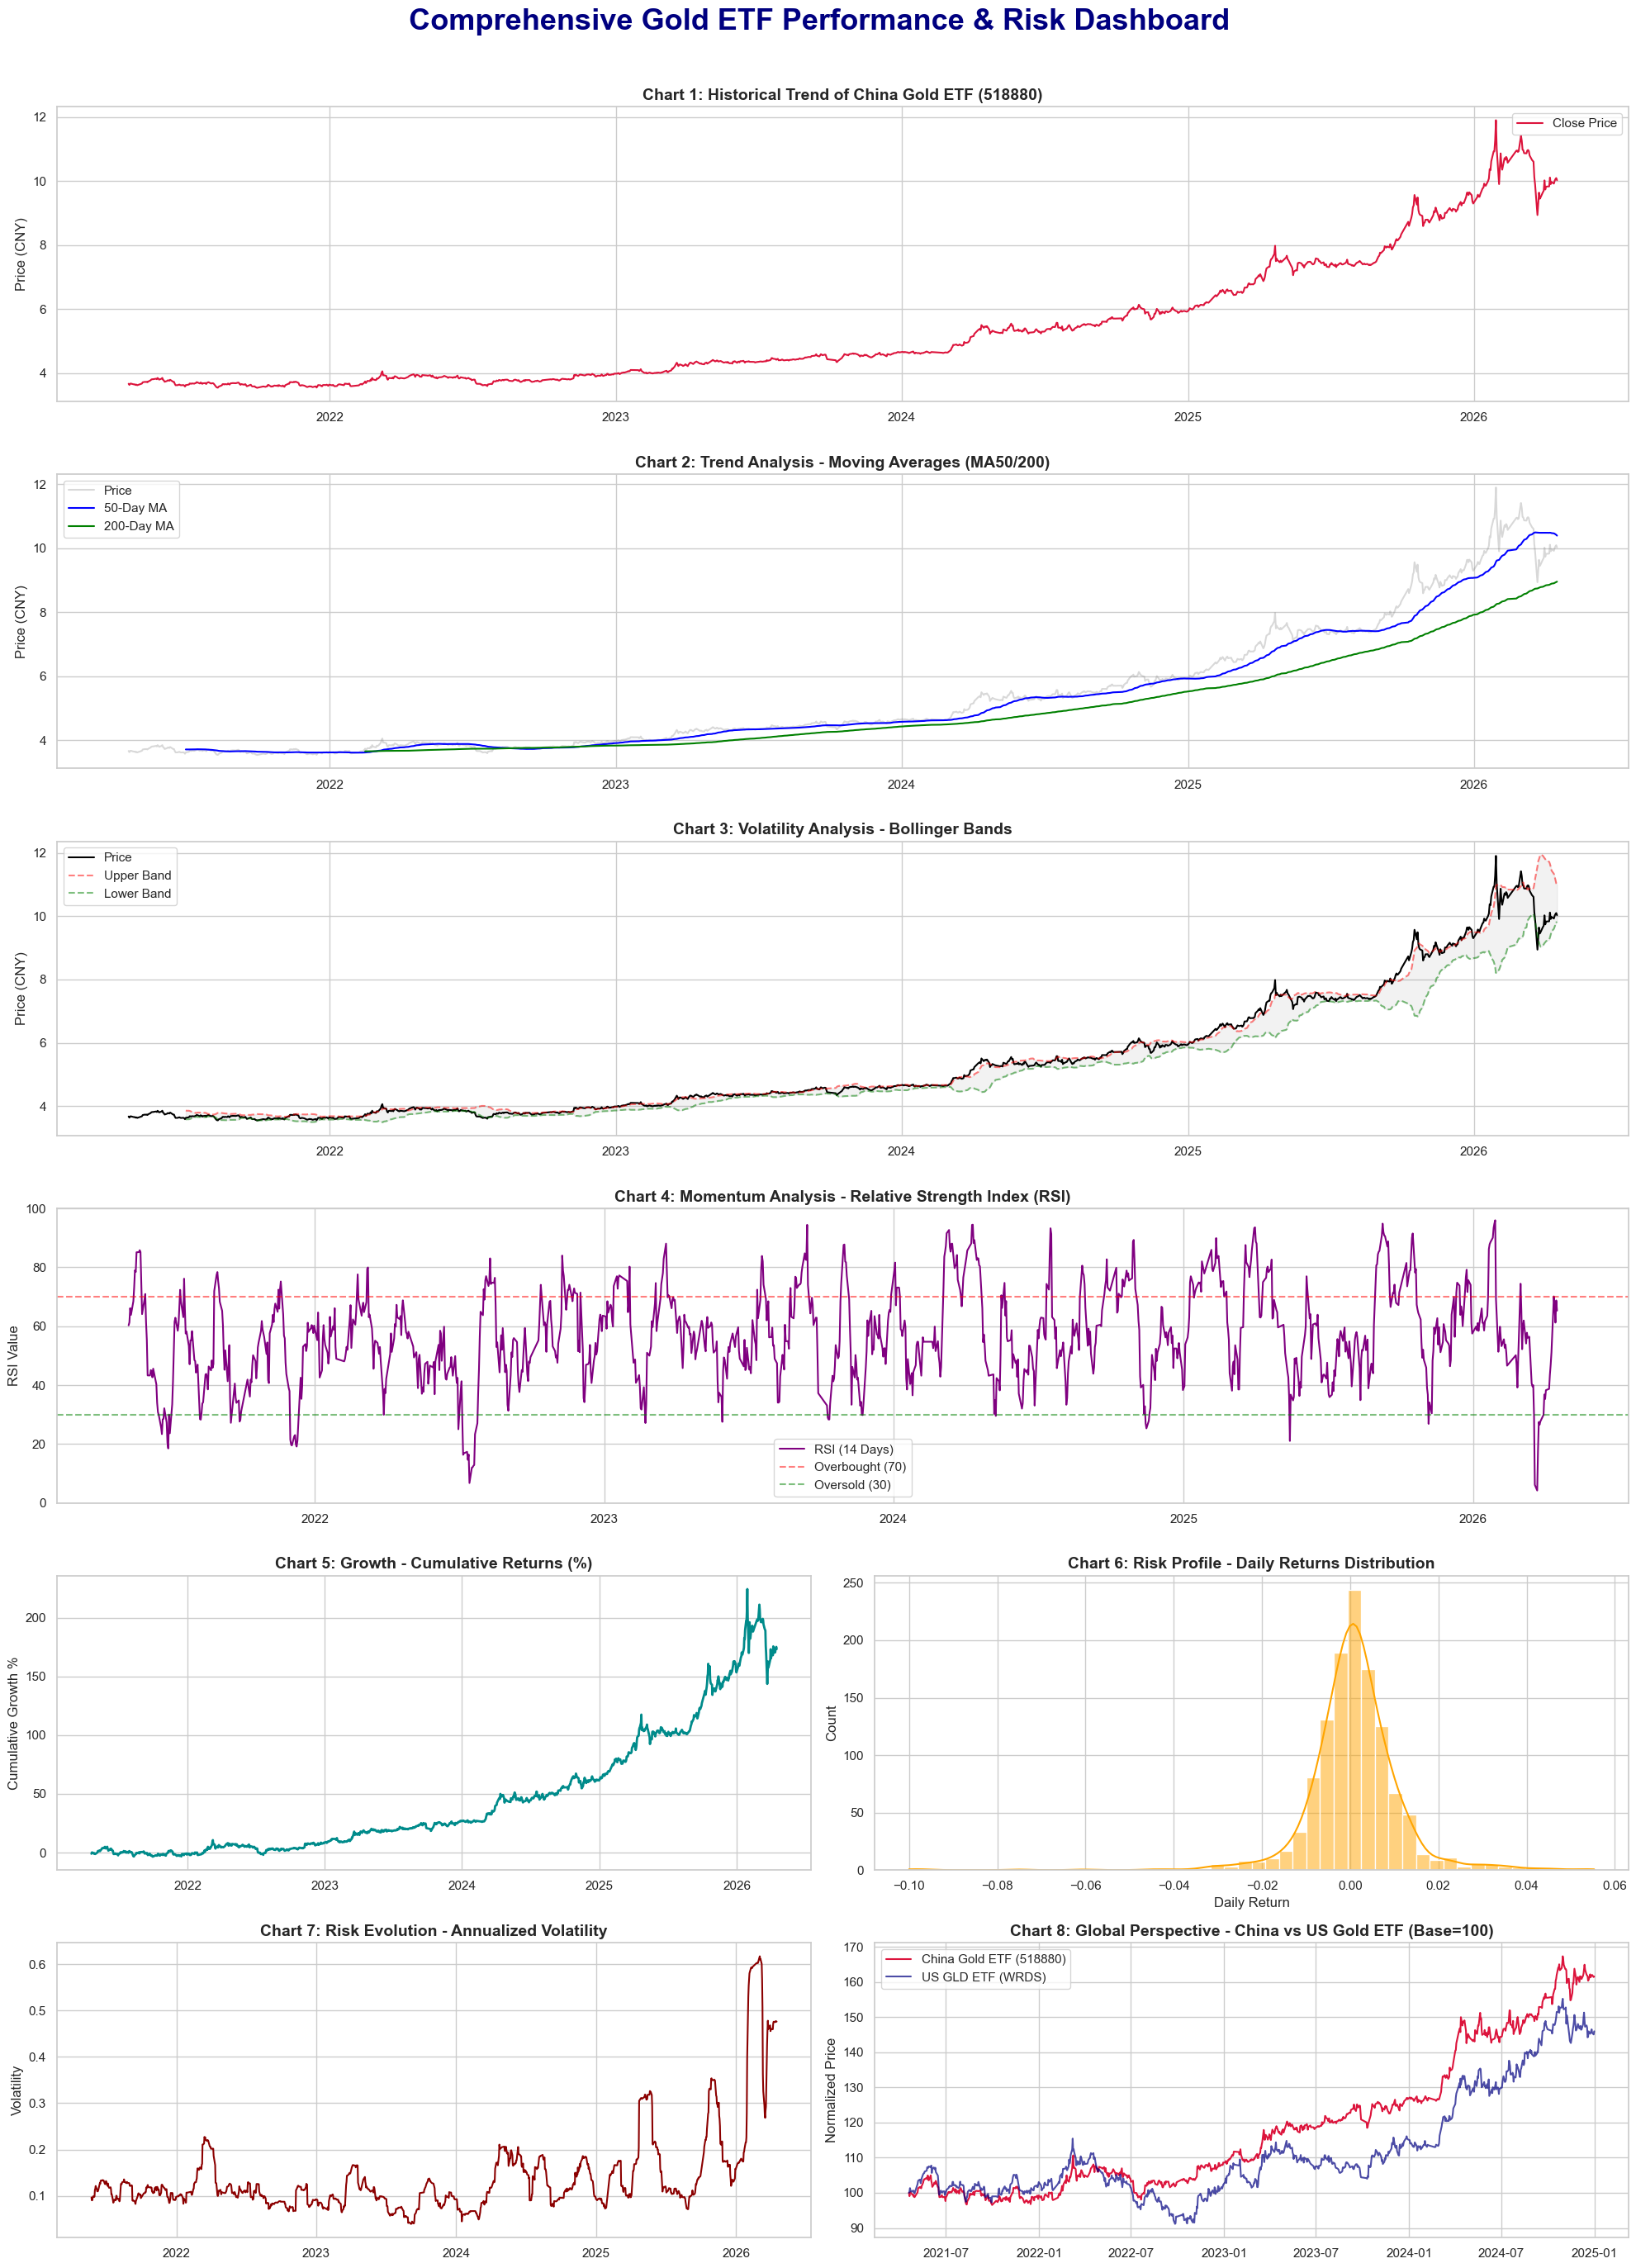

✅ Optimized 8-Chart Dashboard generated and saved successfully!
📁 Files 'gold_analysis_dashboard.png' and 'gold_analysis_dashboard.pdf' are now in your folder.


In [11]:
# ==========================================
# CELL 3: The 8-Chart Master Dashboard
# ==========================================
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import seaborn as sns

print("\nStep 3: Generating the 8-Chart Dashboard...")

try:
    # 设置全局字体大小和主题
    plt.rcParams.update({'font.size': 10})
    sns.set_theme(style="whitegrid")
    
    # 创建超大画布
    fig = plt.figure(figsize=(20, 28))
    
    # 添加全局大标题 (Super Title)
    fig.suptitle('Comprehensive Gold ETF Performance & Risk Dashboard', fontsize=26, fontweight='bold', color='navy')
    
    # 设置 6行2列 的布局布局
    gs = gridspec.GridSpec(6, 2, figure=fig) 
    
    # --- Chart 1: Basic Price Trend ---
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(df_china.index, df_china['Close'], color='crimson', label='Close Price')
    ax1.set_title('Chart 1: Historical Trend of China Gold ETF (518880)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price (CNY)')
    ax1.legend()

    # --- Chart 2: Moving Averages (Trend Analysis) ---
    ax2 = fig.add_subplot(gs[1, :])
    ax2.plot(df_china.index, df_china['Close'], color='gray', alpha=0.3, label='Price')
    ax2.plot(df_china.index, df_china['MA50'], color='blue', label='50-Day MA')
    ax2.plot(df_china.index, df_china['MA200'], color='green', label='200-Day MA')
    ax2.set_title('Chart 2: Trend Analysis - Moving Averages (MA50/200)', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Price (CNY)')
    ax2.legend()

    # --- Chart 3: Bollinger Bands (Volatility Zone) ---
    ax3 = fig.add_subplot(gs[2, :])
    ax3.plot(df_china.index, df_china['Close'], color='black', label='Price')
    ax3.plot(df_china.index, df_china['Upper_Band'], color='red', linestyle='--', alpha=0.5, label='Upper Band')
    ax3.plot(df_china.index, df_china['Lower_Band'], color='green', linestyle='--', alpha=0.5, label='Lower Band')
    ax3.fill_between(df_china.index, df_china['Upper_Band'], df_china['Lower_Band'], color='gray', alpha=0.1)
    ax3.set_title('Chart 3: Volatility Analysis - Bollinger Bands', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Price (CNY)')
    ax3.legend()

    # --- Chart 4: RSI (Momentum Analysis) ---
    ax4 = fig.add_subplot(gs[3, :])
    ax4.plot(df_china.index, df_china['RSI'], color='purple', label='RSI (14 Days)')
    ax4.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
    ax4.axhline(30, color='green', linestyle='--', alpha=0.5, label='Oversold (30)')
    ax4.set_title('Chart 4: Momentum Analysis - Relative Strength Index (RSI)', fontsize=14, fontweight='bold')
    ax4.set_ylabel('RSI Value')
    ax4.set_ylim(0, 100)
    ax4.legend()

    # --- Chart 5: 【修复版】Cumulative Returns (取代了空的成交量图) ---
    ax5 = fig.add_subplot(gs[4, 0])
    ax5.plot(df_china.index, df_china['Cum_Returns'] * 100, color='darkcyan', lw=2)
    ax5.set_title('Chart 5: Growth - Cumulative Returns (%)', fontsize=14, fontweight='bold')
    ax5.set_ylabel('Cumulative Growth %')

    # --- Chart 6: Returns Distribution (Histogram) ---
    ax6 = fig.add_subplot(gs[4, 1])
    sns.histplot(df_china['Returns'].dropna(), bins=50, kde=True, color='orange', ax=ax6)
    ax6.set_title('Chart 6: Risk Profile - Daily Returns Distribution', fontsize=14, fontweight='bold')
    ax6.set_xlabel('Daily Return')

    # --- Chart 7: Rolling Volatility (Line Chart) ---
    ax7 = fig.add_subplot(gs[5, 0])
    ax7.plot(df_china.index, df_china['Volatility'], color='darkred')
    ax7.set_title('Chart 7: Risk Evolution - Annualized Volatility', fontsize=14, fontweight='bold')
    ax7.set_ylabel('Volatility')

    # --- Chart 8: WRDS Cross-Market Comparison ---
    ax8 = fig.add_subplot(gs[5, 1])
    ax8.plot(df_merged.index, df_merged['China_Norm'], color='crimson', label='China Gold ETF (518880)')
    ax8.plot(df_merged.index, df_merged['US_Norm'], color='navy', label='US GLD ETF (WRDS)', alpha=0.7)
    ax8.set_title('Chart 8: Global Perspective - China vs US Gold ETF (Base=100)', fontsize=14, fontweight='bold')
    ax8.set_ylabel('Normalized Price')
    ax8.legend(loc='upper left')

    # 调整布局，为大标题留出空间
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # --- 自动保存图片和 PDF ---
    plt.savefig('gold_analysis_dashboard.png', dpi=300, bbox_inches='tight')
    plt.savefig('gold_analysis_dashboard.pdf', bbox_inches='tight')
    
    plt.show()
    
    print("✅ Optimized 8-Chart Dashboard generated and saved successfully!")
    print("📁 Files 'gold_analysis_dashboard.png' and 'gold_analysis_dashboard.pdf' are now in your folder.")

except Exception as e:
    print(f"❌ Error occurred: {e}")